# Load Dataset

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from pathlib import Path

def find_repo_root(marker="README.md"):
    """Walk up from current path to find the repo root containing `marker`."""
    current = Path().resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find repo root with marker '{marker}'")

# Find repo root using a known file at the root
repo_root = find_repo_root("README.md")

# Path to the CSV file
# GFOC_path = repo_root / Path('Dataset/Dataset_MSc/GFOC_RDCDFI.csv')
# Path to the parquet file
GFOC_path = repo_root / Path('Dataset/Dataset_MSc/GFOC_RDCDFI.parquet')

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['orbital_decay']

# Try to load with limited columns first
try:
    # GFOC_data = pd.read_csv(GFOC_path, usecols=columns_needed, low_memory=True)
    GFOC_data = pd.read_parquet(GFOC_path, columns=columns_needed)
    # reset index to bring 'time' back as a column
    GFOC_data = GFOC_data.reset_index()
    print(f"Successfully loaded data with shape: {GFOC_data.shape}")
    print(GFOC_data.head())
except MemoryError:
    print("MemoryError: Unable to load data with specified columns.")
    # print("Still running out of memory. Loading in chunks...")
    # # If still out of memory, load in chunks
    # chunk_list = []
    # chunksize = 50000  # Adjust this number based on your available memory
    
    # for chunk in pd.read_csv(GFOC_path, usecols=columns_needed, chunksize=chunksize, low_memory=True):
    #     chunk_list.append(chunk)
    
    # GFOC_data = pd.concat(chunk_list, ignore_index=True)
    # print(f"Successfully loaded data in chunks with shape: {GFOC_data.shape}")

Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


# Import Flags

In [21]:
# Path to the CSV files for shocks, helio, and RC
Shock_path = repo_root / Path('Dataset/Dataset_IPshocks/shocks_GFOC.csv')
Helio_path = repo_root / Path('Dataset/Dataset_ICMECAT/helio4cast_icmecat_GFOC.csv')
RC_path = repo_root / Path('Dataset/Dataset_ICMECAT/RC_icmecat_GFOC.csv')

Shock = pd.read_csv(Shock_path)
Helio = pd.read_csv(Helio_path)
RC = pd.read_csv(RC_path)

# Plot data

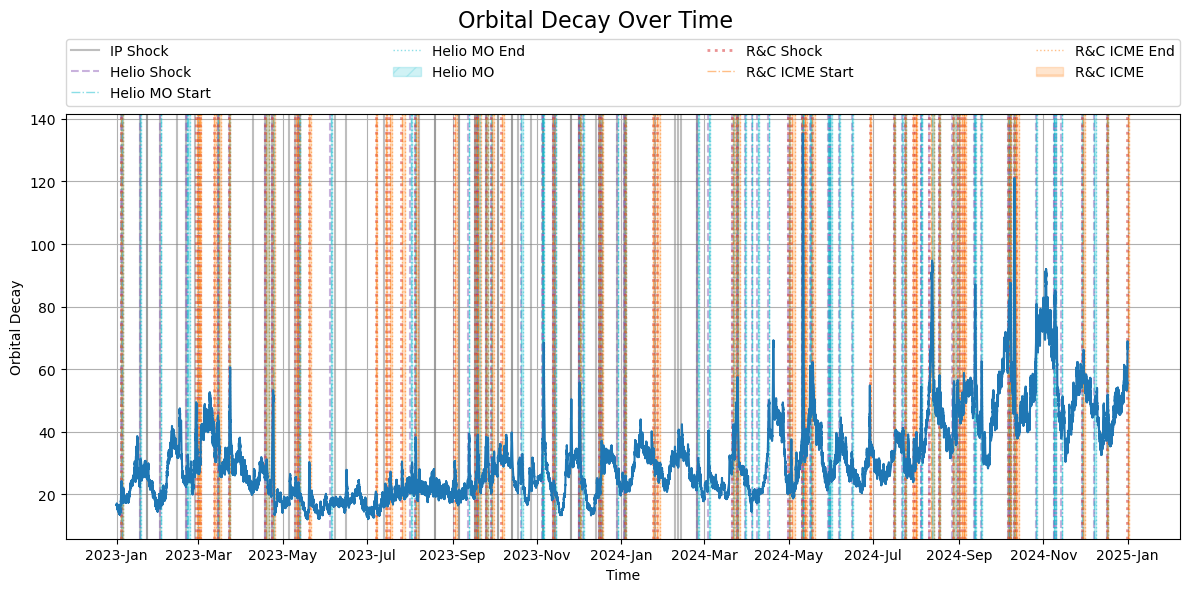

In [29]:
import matplotlib.dates as mdates
import numpy as np

# =========================== Input ===================================
# start_date = '2023-05-01 00:00:00'
# end_date = '2023-10-01 00:00:00'
start_date = GFOC_data['time'].values[0]
end_date = GFOC_data['time'].values[-1] #removed gap by ignoring the last 4321 values

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 2  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

# plt.style.use('dark_background')
plt.style.use('default')

# Helper function for tick formatting
def format_ticks(ax, tick_interval, tick_step):
    if tick_interval == 'monthly':
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))                         
    elif tick_interval == 'daily':
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    elif tick_interval == 'hourly':
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=0)

# =====================================================================
# Time conversion and subsetting

# GFOC_data = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)]
# GFOC_time = GFOC_data['time']

GFOC_subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)]
GFOC_time = GFOC_subset['time']

# time conversion
GFOC_time = pd.to_datetime(GFOC_time, format='%Y-%m-%d %H:%M:%S')

# =====================================================================
# Flags
Shock_subset = Shock[pd.to_datetime(Shock['Time'], format='%Y-%m-%d %H:%M:%S') >= pd.to_datetime(start_date)]
Shock_subset = Shock_subset[pd.to_datetime(Shock_subset['Time'], format='%Y-%m-%d %H:%M:%S') <= pd.to_datetime(end_date)]
Helio_subset = Helio[pd.to_datetime(Helio['mo_end_time'], format='%Y-%m-%d %H:%M:%S') >= pd.to_datetime(start_date)]
Helio_subset = Helio_subset[pd.to_datetime(Helio_subset['icme_start_time'], format='%Y-%m-%d %H:%M:%S') <= pd.to_datetime(end_date)]
RC_subset = RC[pd.to_datetime(RC['ICME_End'], format='%Y-%m-%d %H:%M:%S') >= pd.to_datetime(start_date)]
RC_subset = RC_subset[pd.to_datetime(RC_subset['Disturbance_time'], format='%Y-%m-%d %H:%M:%S') <= pd.to_datetime(end_date)]

Shock_flag = pd.to_datetime(Shock_subset['Time'])
Helios_shock_flag = pd.to_datetime(Helio_subset['icme_start_time'])
Helios_mostart_flag = pd.to_datetime(Helio_subset['mo_start_time'])
Helios_moend_flag = pd.to_datetime(Helio_subset['mo_end_time'])
RC_shock_flag = pd.to_datetime(RC_subset['Disturbance_time'])
RC_start_flag = pd.to_datetime(RC_subset['ICME_Start'])
RC_end_flag = pd.to_datetime(RC_subset['ICME_End'])



# =====================================================================
# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# flags
for t in Shock_flag:
    ax.axvline(t, color='tab:gray', alpha=0.5, linestyle='-', linewidth=1.5, label='IP Shock')
    
    # Helio Shock flags
for t in Helios_shock_flag:
    ax.axvline(t, color='tab:purple', alpha=0.5, linestyle='--', linewidth=1.5, label='Helio Shock')

    # Helios MO flags
for tstart, tend in zip(Helios_mostart_flag, Helios_moend_flag):
    ax.axvline(tstart, color='tab:cyan', alpha=0.5, linestyle='-.', linewidth=1.0, label='Helio MO Start')
    ax.axvline(tend, color='tab:cyan', alpha=0.5, linestyle=':', linewidth=1.0, label='Helio MO End')
    ax.axvspan(tstart, tend, color='tab:cyan', alpha=0.2, hatch = '//', label='Helio MO')
    
    # RC Shock flags
for t in RC_shock_flag:
    ax.axvline(t, color='tab:red', alpha=0.5, linestyle=':', linewidth=2.0, label='R&C Shock')

    # RC flags
for tstart, tend in zip(RC_start_flag, RC_end_flag):
    ax.axvline(tstart, color='tab:orange', alpha=0.5, linestyle='-.', linewidth=1.0, label='R&C ICME Start')
    ax.axvline(tend, color='tab:orange', alpha=0.5, linestyle=':', linewidth=1.0, label='R&C ICME End')
    ax.axvspan(tstart, tend, color='tab:orange', alpha=0.2, hatch = '-', label='R&C ICME')


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
         ncols=4, mode="expand", borderaxespad=0.)

# ax.plot(GFOC_time, GFOC_data['orbital_decay'], label='Orbital Decay')
ax.plot(GFOC_time, GFOC_subset['orbital_decay'], label='Orbital Decay')
format_ticks(ax, tick_interval, tick_step)
ax.set_xlabel('Time')
ax.set_ylabel('Orbital Decay')
fig.suptitle('Orbital Decay Over Time', fontsize=16)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

# Optional: Create Dataset without Events

I use different buffers to also remove any short term effect of the events (just in case) before and (more important) after the event. The length of the buffers is debatable. I choose them by looking at some events and estimating duration of the effect by eye. Then I made the buffer bigger than the estimate I made (feeling like an engineer).

In [23]:
filtered_data = GFOC_data.copy()
filtered_data['time'] = pd.to_datetime(filtered_data['time'], format='%Y-%m-%d %H:%M:%S')

# Buffer times
IP_buffer = pd.Timedelta(days=2)
buffer = pd.Timedelta(hours=24)

# Columns to mask (all except 'time')
mask_cols = filtered_data.columns.difference(['time'])

# --- Mask Helios MO flagged intervals (with buffer) ---
for start, end in zip(Helios_shock_flag, Helios_moend_flag):
    mask = (filtered_data['time'] >= (start - buffer)) & (filtered_data['time'] <= (end + IP_buffer))
    filtered_data.loc[mask, mask_cols] = np.nan

# --- Mask RC flagged intervals (with buffer) ---
for start, end in zip(RC_shock_flag, RC_end_flag):
    mask = (filtered_data['time'] >= (start - buffer)) & (filtered_data['time'] <= (end + buffer))
    filtered_data.loc[mask, mask_cols] = np.nan

# --- Mask single-time shock events (with buffer) ---
for t_shock in Shock_flag:
    mask = (filtered_data['time'] >= t_shock) & (filtered_data['time'] <= (t_shock + IP_buffer))
    filtered_data.loc[mask, mask_cols] = np.nan

## Control: Plot filtered Data

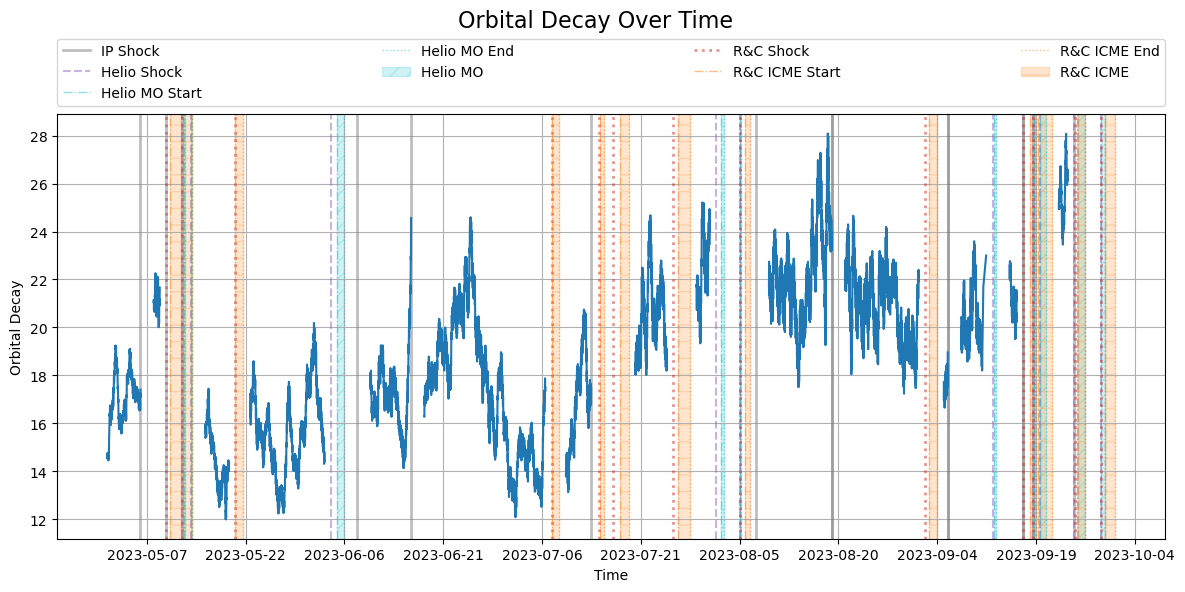

In [24]:
import matplotlib.dates as mdates
import numpy as np

# =========================== Input ===================================
start_date = '2023-05-01 00:00:00'
end_date = '2023-10-01 00:00:00'
# start_date = GFOC_data['time'].values[0]
# end_date = GFOC_data['time'].values[-4322] #removed gap by ignoring the last 4321 values

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'daily'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 15  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

# plt.style.use('dark_background')
plt.style.use('default')

# Helper function for tick formatting
def format_ticks(ax, tick_interval, tick_step):
    if tick_interval == 'monthly':
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))                         
    elif tick_interval == 'daily':
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    elif tick_interval == 'hourly':
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_step))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    ax.tick_params(axis='x', rotation=0)

# =====================================================================
# Time conversion and subsetting

# GFOC_data = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)]
# GFOC_time = GFOC_data['time']

subset = filtered_data[(filtered_data['time'] >= start_date) & (filtered_data['time'] <= end_date)]
subset_time = subset['time']

# time conversion
subset_time = pd.to_datetime(subset_time, format='%Y-%m-%d %H:%M:%S')

# =====================================================================
# Flags
Shock_subset = Shock[pd.to_datetime(Shock['Time'], format='%Y-%m-%d %H:%M:%S') >= pd.to_datetime(start_date)]
Shock_subset = Shock_subset[pd.to_datetime(Shock_subset['Time'], format='%Y-%m-%d %H:%M:%S') <= pd.to_datetime(end_date)]
Helio_subset = Helio[pd.to_datetime(Helio['mo_end_time'], format='%Y-%m-%d %H:%M:%S') >= pd.to_datetime(start_date)]
Helio_subset = Helio_subset[pd.to_datetime(Helio_subset['icme_start_time'], format='%Y-%m-%d %H:%M:%S') <= pd.to_datetime(end_date)]
RC_subset = RC[pd.to_datetime(RC['ICME_End'], format='%Y-%m-%d %H:%M:%S') >= pd.to_datetime(start_date)]
RC_subset = RC_subset[pd.to_datetime(RC_subset['Disturbance_time'], format='%Y-%m-%d %H:%M:%S') <= pd.to_datetime(end_date)]

Shock_flag = pd.to_datetime(Shock_subset['Time'])
Helios_shock_flag = pd.to_datetime(Helio_subset['icme_start_time'])
Helios_mostart_flag = pd.to_datetime(Helio_subset['mo_start_time'])
Helios_moend_flag = pd.to_datetime(Helio_subset['mo_end_time'])
RC_shock_flag = pd.to_datetime(RC_subset['Disturbance_time'])
RC_start_flag = pd.to_datetime(RC_subset['ICME_Start'])
RC_end_flag = pd.to_datetime(RC_subset['ICME_End'])



# =====================================================================
# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# flags
for t in Shock_flag:
    ax.axvline(t, color='tab:gray', alpha=0.5, linestyle='-', linewidth=2, label='IP Shock')
    
    # Helio Shock flags
for t in Helios_shock_flag:
    ax.axvline(t, color='tab:purple', alpha=0.5, linestyle='--', linewidth=1.5, label='Helio Shock')

    # Helios MO flags
for tstart, tend in zip(Helios_mostart_flag, Helios_moend_flag):
    ax.axvline(tstart, color='tab:cyan', alpha=0.5, linestyle='-.', linewidth=1.0, label='Helio MO Start')
    ax.axvline(tend, color='tab:cyan', alpha=0.5, linestyle=':', linewidth=1.0, label='Helio MO End')
    ax.axvspan(tstart, tend, color='tab:cyan', alpha=0.2, hatch = '//', label='Helio MO')
    
    # RC Shock flags
for t in RC_shock_flag:
    ax.axvline(t, color='tab:red', alpha=0.5, linestyle=':', linewidth=2.0, label='R&C Shock')

    # RC flags
for tstart, tend in zip(RC_start_flag, RC_end_flag):
    ax.axvline(tstart, color='tab:orange', alpha=0.5, linestyle='-.', linewidth=1.0, label='R&C ICME Start')
    ax.axvline(tend, color='tab:orange', alpha=0.5, linestyle=':', linewidth=1.0, label='R&C ICME End')
    ax.axvspan(tstart, tend, color='tab:orange', alpha=0.2, hatch = '-', label='R&C ICME')


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
         ncols=4, mode="expand", borderaxespad=0.)

# ax.plot(GFOC_time, GFOC_data['orbital_decay'], label='Orbital Decay')
ax.plot(subset_time, subset['orbital_decay'], label='Orbital Decay')
format_ticks(ax, tick_interval, tick_step)
ax.set_xlabel('Time')
ax.set_ylabel('Orbital Decay')
fig.suptitle('Orbital Decay Over Time', fontsize=16)
plt.grid(True)
plt.tight_layout(rect=[0, 0, 1, 1.02])
plt.show()

## Create csv

In [25]:
filtered_data.to_csv('filtered_GFOC_data.csv', index=False)